In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-fraud-detection-dataset/credit_card_fraud_10k.csv


# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("/kaggle/input/credit-card-fraud-detection-dataset/credit_card_fraud_10k.csv")
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [5]:
df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [6]:
df.tail(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9990,9991,107.74,12,Travel,1,0,26,2,39,0
9991,9992,70.78,18,Clothing,0,0,67,1,40,0
9992,9993,114.66,20,Travel,0,0,64,2,51,0
9993,9994,307.41,0,Grocery,0,1,92,1,26,0
9994,9995,23.96,22,Food,0,0,28,2,19,0
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [7]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [8]:
df.describe(include='O')

,merchant_category
count,10000
unique,5
top,Food
freq,2093


# DATA QUALITY CHECK

In [9]:
df.isna().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [10]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [11]:
df.nunique()

transaction_id         10000
amount                  8788
transaction_hour          24
merchant_category          5
foreign_transaction        2
location_mismatch          2
device_trust_score        75
velocity_last_24h         10
cardholder_age            52
is_fraud                   2
dtype: int64

# FRAUD DISTRIBUTION

Fraud Rate: 1.51%


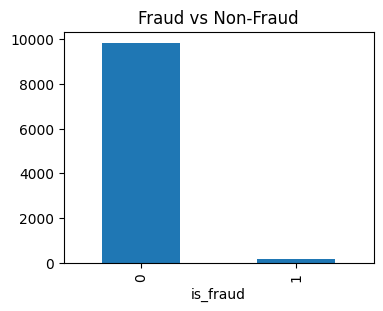

In [12]:
fraud_counts = df["is_fraud"].value_counts()
fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

plt.figure(figsize=(4,3))
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud")
plt.show()

# NUMERIC DISTRIBUTIONS


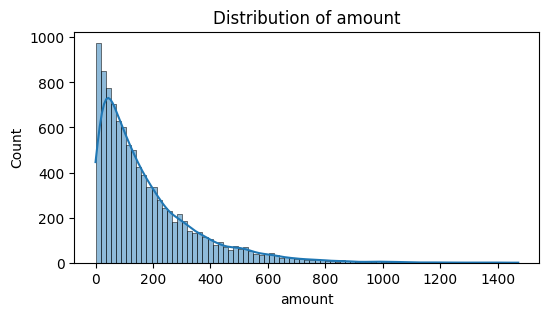

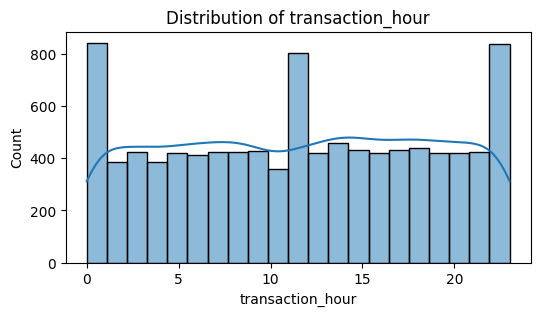

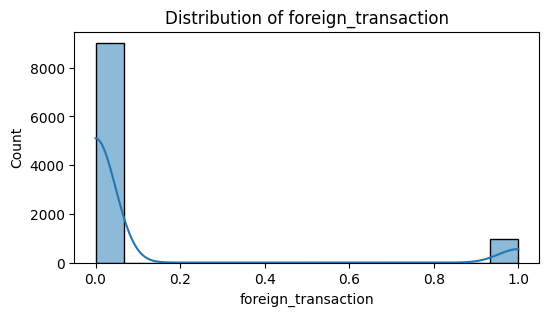

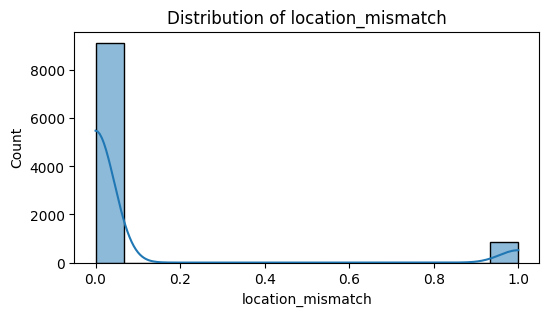

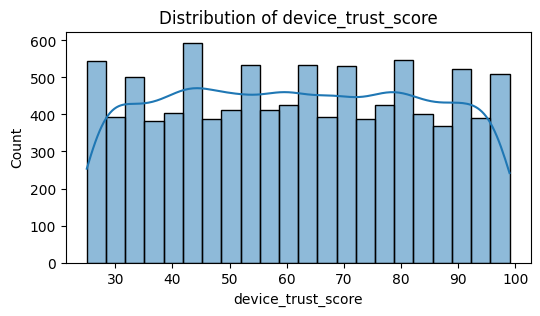

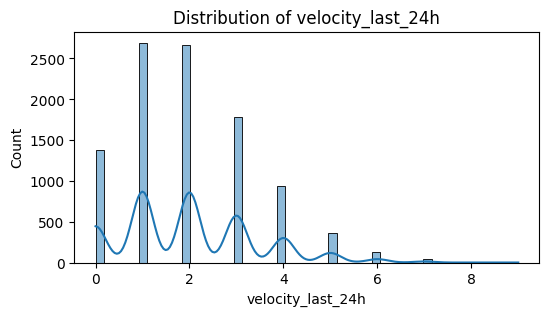

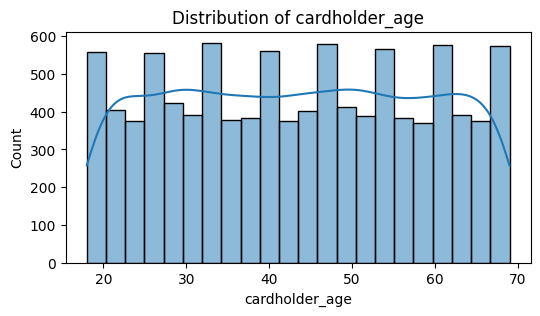

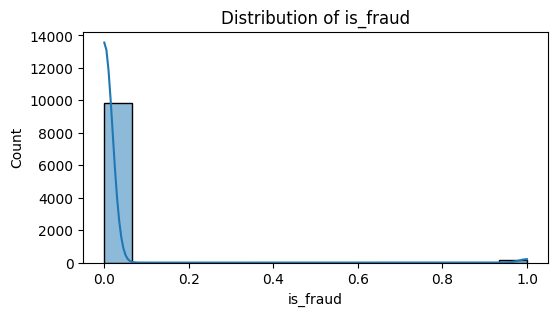

In [13]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,3))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

# OUTLIER ANALYSIS

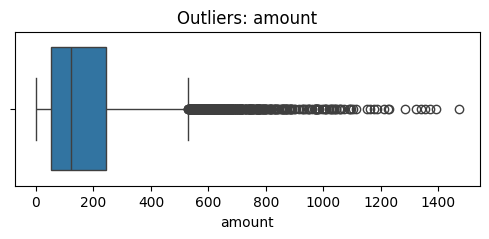

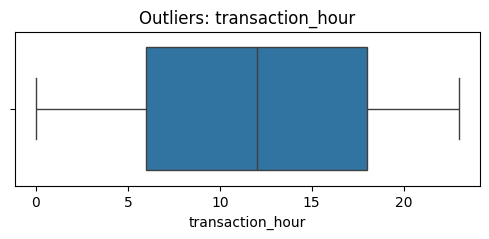

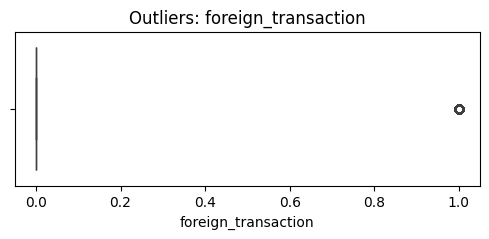

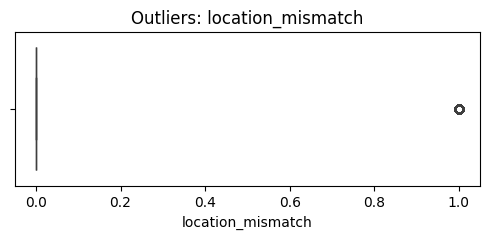

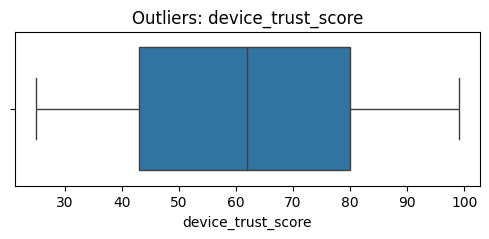

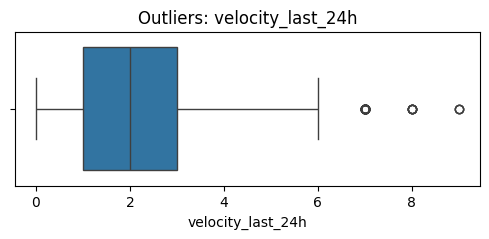

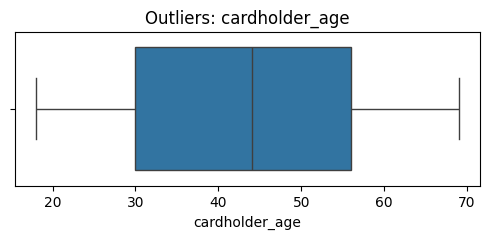

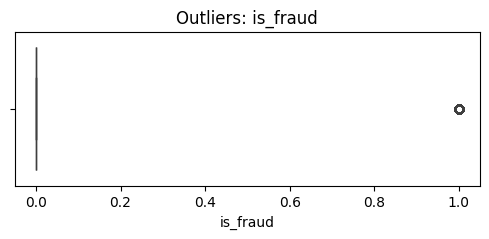

In [14]:
for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,2))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers: {col}")
        plt.show()

# FRAUD BEHAVIOR ANALYSIS


In [15]:
group_stats = df.groupby("is_fraud").mean(numeric_only=True)
group_stats

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,,
0,5004.129861,175.333015,11.712154,0.090974,0.079704,62.165804,1.990557,43.469794
1,4763.741722,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351


# FOREIGN & LOCATION RISK


Fraud % by foreign_transaction:
 is_fraud                 0     1
foreign_transaction             
0                    99.24  0.76
1                    91.62  8.38


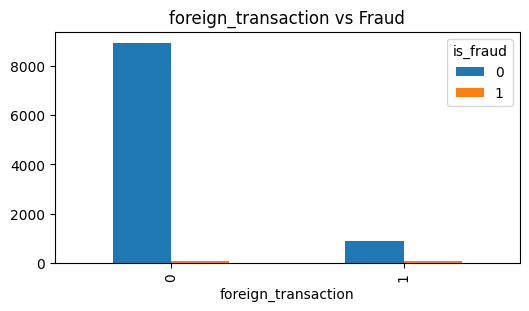


Fraud % by location_mismatch:
 is_fraud               0     1
location_mismatch             
0                  99.14  0.86
1                  91.60  8.40


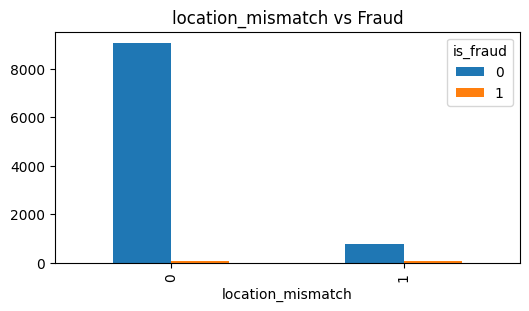

In [16]:
binary_cols = ["foreign_transaction", "location_mismatch"]

for col in binary_cols:
    table = pd.crosstab(df[col], df["is_fraud"], normalize="index") * 100
    print(f"\nFraud % by {col}:\n", table.round(2))

    pd.crosstab(df[col], df["is_fraud"]).plot(kind="bar", figsize=(6,3))
    plt.title(f"{col} vs Fraud")
    plt.show()

# AMOUNT RISK LEVEL


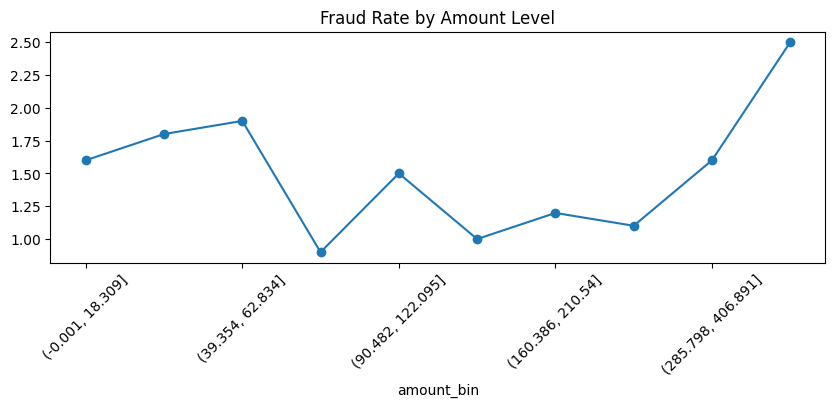

In [17]:
df["amount_bin"] = pd.qcut(df["amount"], q=10)

amount_risk = df.groupby("amount_bin")["is_fraud"].mean() * 100

plt.figure(figsize=(10,3))
amount_risk.plot(marker="o")
plt.title("Fraud Rate by Amount Level")
plt.xticks(rotation=45)
plt.show()

# TRANSACTION HOUR PATTERN

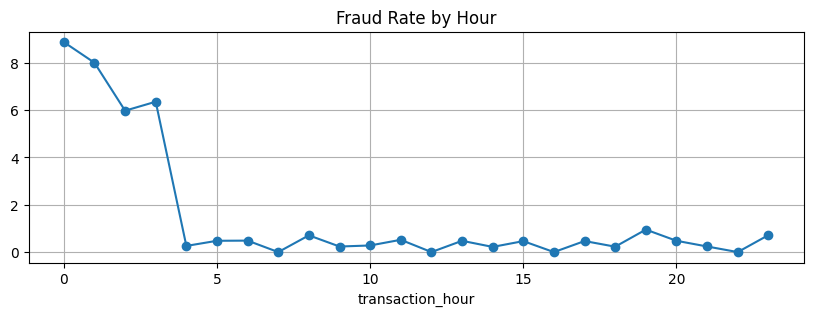

In [18]:
hour_pattern = df.groupby("transaction_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10,3))
hour_pattern.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.grid(True)
plt.show()

# DEVICE TRUST SCORE

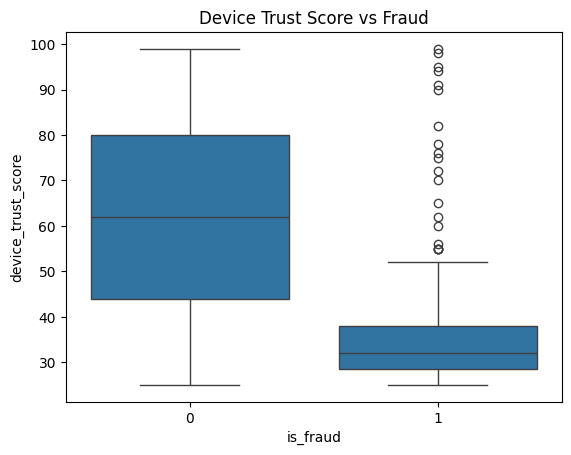

In [19]:
sns.boxplot(data=df, x="is_fraud", y="device_trust_score")
plt.title("Device Trust Score vs Fraud")
plt.show()

# VELOCITY ANALYSIS

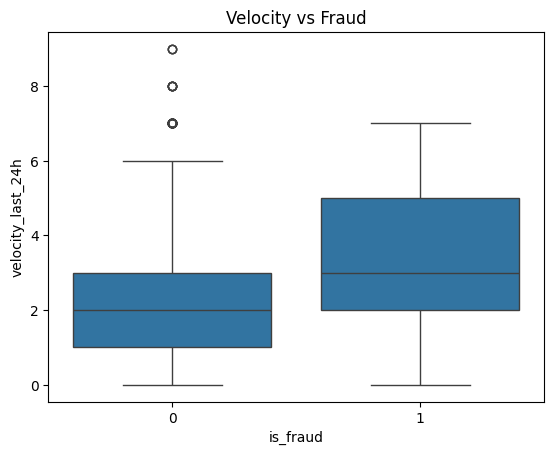

In [20]:
sns.boxplot(data=df, x="is_fraud", y="velocity_last_24h")
plt.title("Velocity vs Fraud")
plt.show()

# CORRELATION MATRIX

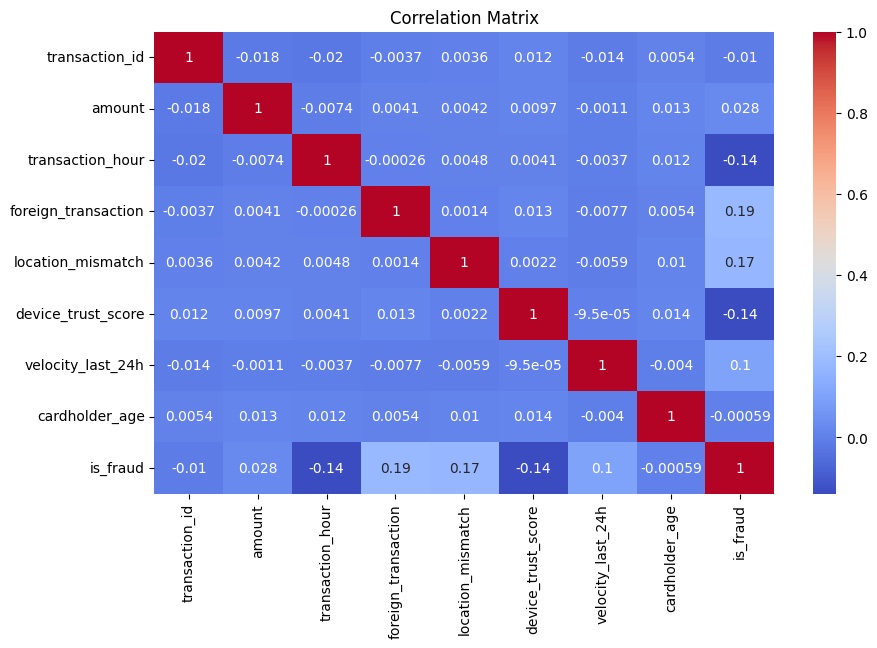

In [21]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# RULE-BASED RISK SCORE

In [22]:
df2 = df.copy()

vel_thr = df2["velocity_last_24h"].quantile(0.9)
trust_thr = df2["device_trust_score"].quantile(0.1)

df2["risk_score"] = 0
df2["risk_score"] += (df2["foreign_transaction"]==1).astype(int)
df2["risk_score"] += (df2["location_mismatch"]==1).astype(int)
df2["risk_score"] += (df2["velocity_last_24h"]>=vel_thr).astype(int)
df2["risk_score"] += (df2["device_trust_score"]<=trust_thr).astype(int)

risk_analysis = df2.groupby("risk_score")["is_fraud"].mean()*100
risk_analysis

risk_score
0      0.031913
1      0.894855
2     16.283186
3     73.684211
4    100.000000
Name: is_fraud, dtype: float64

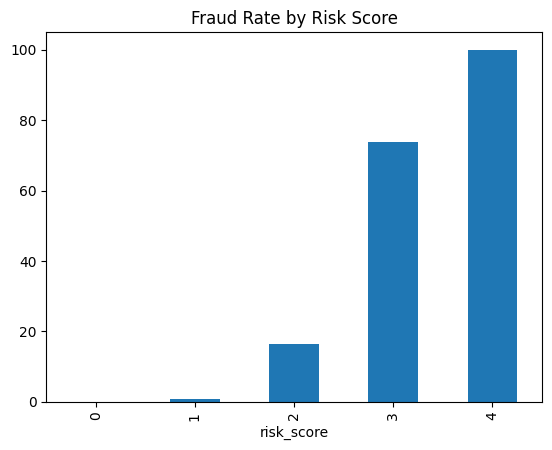

In [23]:
risk_analysis.plot(kind="bar")
plt.title("Fraud Rate by Risk Score")
plt.show()

# MERCHANT CATEGORY HOTSPOTS

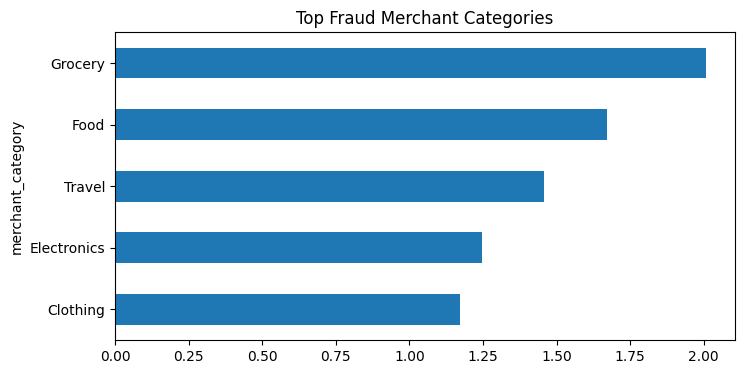

In [24]:
cat_risk = df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)*100

top10 = cat_risk.head(10)

top10.sort_values().plot(kind="barh", figsize=(8,4))
plt.title("Top Fraud Merchant Categories")
plt.show()